In [1]:
!pip uninstall odc-stac -y --quiet
!pip install odc-stac --quiet
!pip uninstall pystac-client -y --quiet
!pip install pystac-client --quiet
!pip install -U pystac --quiet

In [2]:
!pip uninstall dea-tools -y --quiet
!pip install dea-tools==0.4.4 --quiet

# Simple Urban Classifier using only SAR 


## Description
1. Load and pre-process Sentinel-1 SAR data
2. Load training data for urban classification from Global Urban Footprint Urban Fraction in the NCI 
3. Train Random Forest Classifier and see results

***

## Getting started

### Load packages
Import Python packages that are used for the analysis.

Use standard import commands; some are shown below. 
Begin with any `iPython` magic commands, followed by standard Python packages, then any additional functionality you need from the `Tools` directory.

In [165]:
%matplotlib inline

import odc.geo.xr
import datacube
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from dea_tools.datahandling import load_ard
from dea_tools.plotting import rgb
from dea_tools.validation import xr_random_sampling
from dea_tools.classification import collect_training_data
from dea_tools.dask import create_local_dask_cluster

from odc.geo import BoundingBox
from pystac_client import Client
from odc.geo.xr import assign_crs


In [4]:
client = create_local_dask_cluster(return_client=True)

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/gianluca.scortechini@ga.gov.au/proxy/8787/status,
Dashboard: /user/gianluca.scortechini@ga.gov.au/proxy/8787/status,Workers: 1
Total threads: 94,Total memory: 665.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:37583,Workers: 1
Dashboard: /user/gianluca.scortechini@ga.gov.au/proxy/8787/status,Total threads: 94
Started: Just now,Total memory: 665.00 GiB
Comm: tcp://127.0.0.1:46203,Total threads: 94
Dashboard: /user/gianluca.scortechini@ga.gov.au/proxy/33055/status,Memory: 665.00 GiB
Nanny: tcp://127.0.0.1:45279,


2025-09-10 01:07:27,949 - distributed.nanny - WARNING - Restarting worker


### Environment set up

In [6]:
dc = datacube.Datacube(app="S1")

### View available collections

In [8]:
dc_measurements = dc.list_measurements()
dc_measurements.loc['ga_s1_nrb_iw_vv_vh_0']

,name,dtype,units,nodata,aliases,flags_definition
measurement,,,,,,
VV_gamma0,VV_gamma0,float32,linear power,NaN,[vv_gamma0],NaN
VH_gamma0,VH_gamma0,float32,linear power,NaN,[vh_gamma0],NaN
mask,mask,uint8,classification,255,NaN,"{'mask': {'bits': [0, 1, 2, 3, 4, 5, 6, 7], 'v..."
number_of_looks,number_of_looks,float32,count,NaN,"[n_looks, nlooks]",NaN
gamma0_to_beta0_ratio,gamma0_to_beta0_ratio,float32,ratio,NaN,NaN,NaN
gamma0_to_sigma0_ratio,gamma0_to_sigma0_ratio,float32,ratio,NaN,NaN,NaN
local_incidence_angle,local_incidence_angle,float32,degrees,NaN,"[lia, LIA]",NaN
incidence_angle,incidence_angle,float32,degrees,NaN,"[ia, IA]",NaN


### View collection metadata

Displaying the result from `get_collection()` will provide an expandable JSON output showing the collection-level metadata. 

In [10]:
dc.index.products.get_by_name("ga_s1_nrb_iw_hh_c0").fields

{'creation_time': None,
 'format': None,
 'label': None,
 'lat': None,
 'lon': None,
 'time': None,
 'beam_id': None,
 'crs_raw': None,
 'burst_id': None,
 'platform': None,
 'scene_id': None,
 'source_id': None,
 'instrument': None,
 'orbit_file': None,
 'orbit_cycle': None,
 'orbit_state': None,
 'region_code': None,
 'orbit_source': None,
 'conversion_eq': None,
 'absolute_orbit': None,
 'product_family': 'sar_ard',
 'relative_orbit': None,
 'dataset_version': None,
 'instrument_mode': None,
 'measurement_type': None,
 'noise_removal_applied': None,
 'observation_direction': None,
 'measurement_convention': None,
 'speckle_filter_applied': None,
 'far_range_incidence_angle': None,
 'near_range_incidence_angle': None,
 'bistatic_correction_applied': None,
 'ionospheric_correction_applied': None,
 'wet_tropospheric_correction_applied': None,
 'static_tropospheric_correction_applied': None}

### Set search parameters

These are primarily used by the search step, but may also be re-used in load

In [251]:
# Products to query
product_to_load = "ga_s1_nrb_iw_vv_vh_0"

# Area of interest
aoi_bbox = BoundingBox(
    left=148.53,
    bottom=-34,#-35.85,
    right= 151.1,#151.32,
    top=-33,#-33.46,
    crs="EPSG:4326"
)

# Date range of interest
start_date = "2024-06-01"
end_date = "2025-06-30"

# Measurements to load
measurements_to_load = ["VV_gamma0", "VH_gamma0", "mask"]

# CRS and resolution
output_crs = "EPSG:3577"
output_res = 20 

# Property or function to group by. "solar_day" is already built into odc-stac
groupy_by_operation = "solar_day"

# Display the Area of Interest on a map
aoi_bbox.explore()

### Run load

Note that the load function takes:
* `items`: a pystac-client items_collection
* `bands`: a list of assets to load
* `intersects`: a geometry to intersect
* `crs`: a coordinate reference system for the output
* `resolution`: a resolution for the output
* `groupby`: a method or property to group by
* `chunks`: (optionally) a dictionary describing how to chunk the data for lazy loading (recommended)


In [17]:
ds = dc.load(
    product=product_to_load,
    measurements=measurements_to_load,
    lat=(aoi_bbox.bottom, aoi_bbox.top),
    lon=(aoi_bbox.left, aoi_bbox.right),
    output_crs=output_crs,
    resolution=(output_res, -output_res),
    time=(start_date, end_date),
    group_by=groupy_by_operation,
    dask_chunks={},
    skip_broken_datasets=True
)

In [18]:
ds

<xarray.Dataset> Size: 104GB
Dimensions:      (time: 128, y: 7176, x: 12528)
Coordinates:
  * time         (time) datetime64[ns] 1kB 2024-06-03T08:39:47.621946 ... 202...
  * y            (y) float64 57kB -3.842e+06 -3.842e+06 ... -3.698e+06
  * x            (x) float64 100kB 1.765e+06 1.765e+06 ... 1.515e+06 1.515e+06
    spatial_ref  int32 4B 3577
Data variables:
    VV_gamma0    (time, y, x) float32 46GB dask.array<chunksize=(1, 7176, 12528), meta=np.ndarray>
    VH_gamma0    (time, y, x) float32 46GB dask.array<chunksize=(1, 7176, 12528), meta=np.ndarray>
    mask         (time, y, x) uint8 12GB dask.array<chunksize=(1, 7176, 12528), meta=np.ndarray>
Attributes:
    crs:           EPSG:3577
    grid_mapping:  spatial_ref

### Speckle filter

In [19]:
sys.path.insert(1, '../../src/')
from speckle_filters import apply_lee_filter


In [20]:
# couldn't import module so copied code here
from scipy.ndimage import uniform_filter
import xarray as xr


# Adapted from https://stackoverflow.com/questions/39785970/speckle-lee-filter-in-python
def lee_filter(img, size):
    """
    Applies the Lee filter to reduce speckle noise in an image.

    Parameters:
    img (ndarray): Input image to be filtered.
    size (int): Size of the uniform filter window.

    Returns:
    ndarray: The filtered image.
    """
    img_mean = uniform_filter(img, size)
    img_sqr_mean = uniform_filter(img**2, size)
    img_variance = img_sqr_mean - img_mean**2

    overall_variance = np.var(img)

    img_weights = img_variance / (img_variance + overall_variance)
    img_output = img_mean + img_weights * (img - img_mean)
    return img_output


# Define a function to apply the Lee filter to a DataArray
def apply_lee_filter(data_array, size=7):
    """
    Applies the Lee filter to the provided DataArray.

    Parameters:
    data_array (xarray.DataArray): The data array to be filtered.
    size (int): Size of the uniform filter window. Default is 7.

    Returns:
    xarray.DataArray: The filtered data array.
    """
    data_array_filled = data_array.fillna(0)
    filtered_data = xr.apply_ufunc(
        lee_filter,
        data_array_filled,
        kwargs={"size": size},
        input_core_dims=[["y", "x"]],
        output_core_dims=[["y", "x"]],
        dask_gufunc_kwargs={"allow_rechunk": True},
        vectorize=True,
        dask="parallelized",
        output_dtypes=[data_array.dtype],
    )
    return filtered_data


In [21]:
ds["VV_gamma0_filtered"] = apply_lee_filter(ds["VV_gamma0"], size=3)
ds["VH_gamma0_filtered"] = apply_lee_filter(ds["VH_gamma0"], size=3)

## Masking

The GA Sentinel-1 backscatter product comes with a mask that indicates invalid pixels, along with pixels impacted by layover and shadow. 

The masks have the following values:
| Value | Property |
| --- | ----------- |
| 0 | Valid | 
| 1 | Shadow |
| 2 | Layover |
| 3 | Shadow and layover |
| 255 / NaN | Invalid |

The following code displays the masks and shows how to apply them.

In [22]:
ds["VV_gamma0_masked"] = xr.where(ds.mask==0, ds["VV_gamma0_filtered"], np.nan)
ds["VH_gamma0_masked"] = xr.where(ds.mask==0, ds["VH_gamma0_filtered"], np.nan)

### Open and pre-process training data file

In [24]:
urban_GUF = xr.open_dataarray('https://thredds.nci.org.au/thredds/dodsC/ub8/au/LandCover/OzWALD_LC/GUF_FractionUrban_Australia.nc')
urban_GUF = urban_GUF.transpose('latitude', 'longitude')
urban_GUF = assign_crs(urban_GUF, crs='EPSG:4326')

In [25]:
urban_GUF = urban_GUF.odc.reproject(how=ds.odc.geobox, resampling='bilinear')

In [26]:
urban = xr.where(urban_GUF>75, 1, 0)
urban = assign_crs(urban.astype('int16'), crs='EPSG:3577')

In [27]:
np.unique(urban)

array([0, 1], dtype=int16)

In [28]:
## N.B.: ideally a random state/random seed should be set
train_points = xr_random_sampling(urban, sampling='manual', manual_class_ratios={'1':500, '0':500})

Class 1: sampling 500 points
Class 0: sampling 500 points


In [29]:
train_points['class'] = train_points['class'].astype(int)

<Axes: >

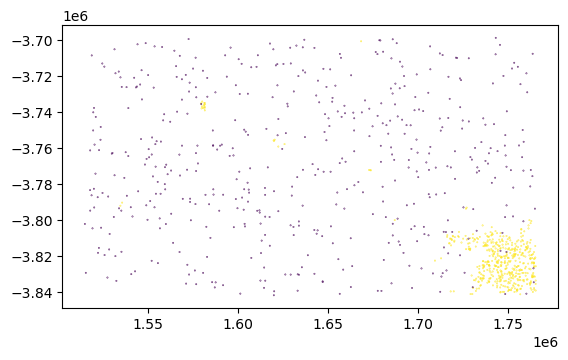

In [240]:
train_points.plot(column='class', markersize=.1)

### Continue processing of SAR data

In [32]:
ds_reduced = ds.drop_vars(['VV_gamma0', 'VH_gamma0', 'mask','VV_gamma0_filtered','VH_gamma0_filtered'])

In [34]:
ds_grouped = ds_reduced.groupby('time.month')

In [35]:
# copy structure and then delete vars to make it empty
ds_final = ds_grouped.mean().drop_vars(['VV_gamma0_masked', 'VH_gamma0_masked'])
ds_final

<xarray.Dataset> Size: 158kB
Dimensions:      (y: 7176, x: 12528, month: 12)
Coordinates:
  * y            (y) float64 57kB -3.842e+06 -3.842e+06 ... -3.698e+06
  * x            (x) float64 100kB 1.765e+06 1.765e+06 ... 1.515e+06 1.515e+06
    spatial_ref  int32 4B 3577
  * month        (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    *empty*
Attributes:
    crs:           EPSG:3577
    grid_mapping:  spatial_ref

In [36]:
ds_final['mean_vv'] = ds_grouped.mean()['VV_gamma0_masked']
ds_final['mean_vh'] = ds_grouped.mean()['VH_gamma0_masked']

In [37]:
ds_final['max_vv'] = ds_grouped.max()['VV_gamma0_masked']
ds_final['max_vh'] = ds_grouped.max()['VH_gamma0_masked']
ds_final['min_vv'] = ds_grouped.min()['VV_gamma0_masked']
ds_final['min_vh'] = ds_grouped.min()['VH_gamma0_masked']
ds_final['std_vv'] = ds_grouped.std()['VV_gamma0_masked']
ds_final['std_vh'] = ds_grouped.std()['VH_gamma0_masked']

In [38]:
ds_final

<xarray.Dataset> Size: 35GB
Dimensions:      (y: 7176, x: 12528, month: 12)
Coordinates:
  * y            (y) float64 57kB -3.842e+06 -3.842e+06 ... -3.698e+06
  * x            (x) float64 100kB 1.765e+06 1.765e+06 ... 1.515e+06 1.515e+06
    spatial_ref  int32 4B 3577
  * month        (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    mean_vv      (month, y, x) float32 4GB dask.array<chunksize=(1, 7176, 12528), meta=np.ndarray>
    mean_vh      (month, y, x) float32 4GB dask.array<chunksize=(1, 7176, 12528), meta=np.ndarray>
    max_vv       (month, y, x) float32 4GB dask.array<chunksize=(1, 7176, 12528), meta=np.ndarray>
    max_vh       (month, y, x) float32 4GB dask.array<chunksize=(1, 7176, 12528), meta=np.ndarray>
    min_vv       (month, y, x) float32 4GB dask.array<chunksize=(1, 7176, 12528), meta=np.ndarray>
    min_vh       (month, y, x) float32 4GB dask.array<chunksize=(1, 7176, 12528), meta=np.ndarray>
    std_vv       (month, y, x) float32 4GB dask.array<chunksize=(1, 7176, 12528), meta=np.ndarray>
    std_vh       (month, y, x) float32 4GB dask.array<chunksize=(1, 7176, 12528), meta=np.ndarray>
Attributes:
    crs:           EPSG:3577
    grid_mapping:  spatial_ref

In [39]:
ds_final = ds_final.compute()

/env/lib/python3.10/site-packages/distributed/client.py:3361: UserWarning: Sending large graph of size 17.92 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/env/lib/python3.10/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(
Error opening source dataset: https://deant-data-public-dev.s3.ap-southeast-2.amazonaws.com/experimental/for_zhengshu/ga_s1_nrb_iw_vv_vh_0/t045_095785_iw1/2024/07/23/ga_s1a_nrb_0-1-0_T045-095785-IW1_20240723T192408Z_VV-gamma0.tif
Ignoring Exception: Read failed. See previous exception for details.
Error opening source dataset: https://deant-data-public-dev.s3.ap-southeast-2.amazonaws.com/experimental/for_zhengshu/

### Create dataframe to train model

In [40]:
cols = ['urban'] + [f'{stat}_{band}_{month}' for stat in ['mean','max','min','std'] for band in ['vv', 'vh'] for month in range(1,13)]

train_df = pd.DataFrame(columns=cols, index=range(len(train_points)))

In [41]:
for i, (c, g) in enumerate(zip(train_points['class'], train_points.geometry)):
    print(i, end='\r')
    ds_point = ds_final.sel(x=g.x, y=g.y, method="nearest")

    # assign response variable (row i, first column, i.e. column index 0)
    train_df.loc[i,'urban'] = c
    
    for col in train_df.columns[1:]:
        var = '_'.join(col.split('_')[:-1])
        month = int(col.split('_')[-1])

        train_df.loc[i, col] = ds_point.sel( month=month)[var].data

In [45]:
train_df.to_csv('samples_df.csv',index=False)

### Split train/test

In [46]:
from sklearn.model_selection import StratifiedShuffleSplit

In [47]:
## N.B.: ideally a random state/random seed should be set
def split_train_test(df, test_size=.2):
    
    # apply stratified sampling
    strat_split = StratifiedShuffleSplit(n_splits=1, test_size=test_size)
    for train_index, test_index in strat_split.split(df, df['urban']):
        train = df.loc[train_index].copy() 
        test = df.loc[test_index].copy() 

    return train, test

In [48]:
# define train_final and test_final dataset
train_final, test_final = split_train_test(train_df) 

In [49]:
predictors = cols[1:]

In [242]:
# define response and explanatory vars train_final dataset
resp_train = train_final['urban'].astype(int).copy() 
expl_train = train_final[predictors].copy()

# define response and explanatory for test_final dataset
resp_test = test_final['urban'].astype(int).copy() 
expl_test = test_final[predictors].copy()

print(f'Train count: {len(resp_train.index)}')
print(f'Test count: {len(resp_test.index)}')

Train count: 800
Test count: 200


### Random forest classifier

In [53]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedShuffleSplit, RandomizedSearchCV, GridSearchCV
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from scipy.stats import randint

In [54]:
## N.B.: ideally a random state/random seed should be set
rf = RandomForestClassifier(n_jobs=-1)

In [55]:
# ranges of possible hyperparameters
hyperpar = {'n_estimators': randint(low=10,high=150),  
            'criterion': ['gini','entropy','log_loss'], 
            'max_depth': randint(low=5,high=20), 
            'min_samples_split': randint(low=2,high=20), 
            'min_samples_leaf': randint(low=1,high=20),
            'max_features': randint(low=1,high=len(predictors)), 
            'bootstrap': [True, False],
            }

In [59]:
## N.B.: ideally a random state/random seed should be set
rf_rand_search = RandomizedSearchCV(rf, 
                                    param_distributions=hyperpar, 
                                    n_iter=200, 
                                    scoring='f1_weighted', 
                                    cv=5, 
                                    verbose= 1, 
                                    n_jobs=-1)
                                    
rf_rand_search.fit(expl_train, resp_train)

Fitting 5 folds for each of 200 candidates, totalling 1000 fits


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(n_jobs=-1),
                   n_iter=200, n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'criterion': ['gini', 'entropy',
                                                      'log_loss'],
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7fa12edd8730>,
                                        'max_features': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7fa12d80bbe0>,
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7fa106dc8e80>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7fa0fe778070>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7fa12edd98d0>},
                   scoring='f1_weighted', verbose=1)

In [60]:
# best model and score of best model
rf_rand_search.best_params_, rf_rand_search.best_score_

({'bootstrap': True,
  'criterion': 'log_loss',
  'max_depth': 14,
  'max_features': 70,
  'min_samples_leaf': 4,
  'min_samples_split': 2,
  'n_estimators': 126},
 0.8446125446812547)

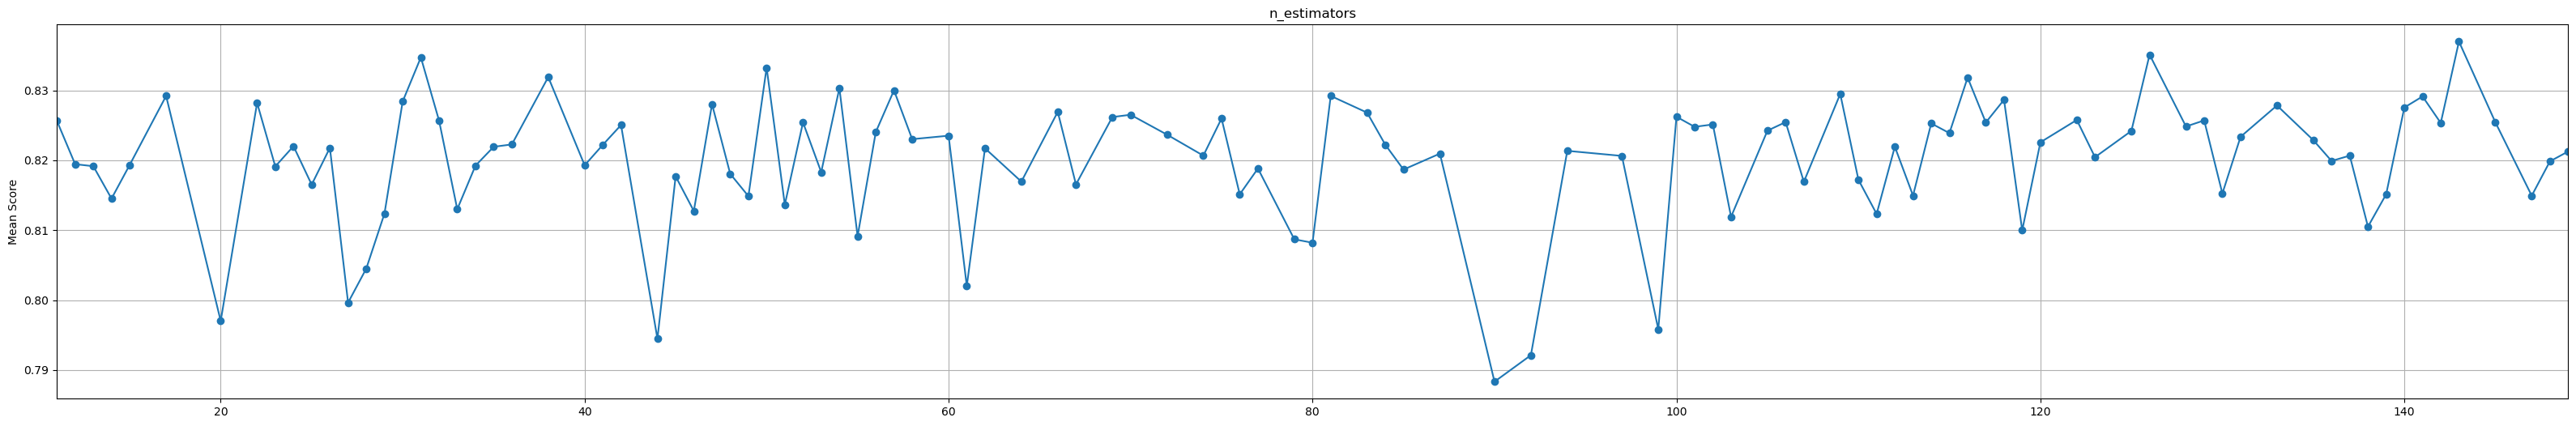

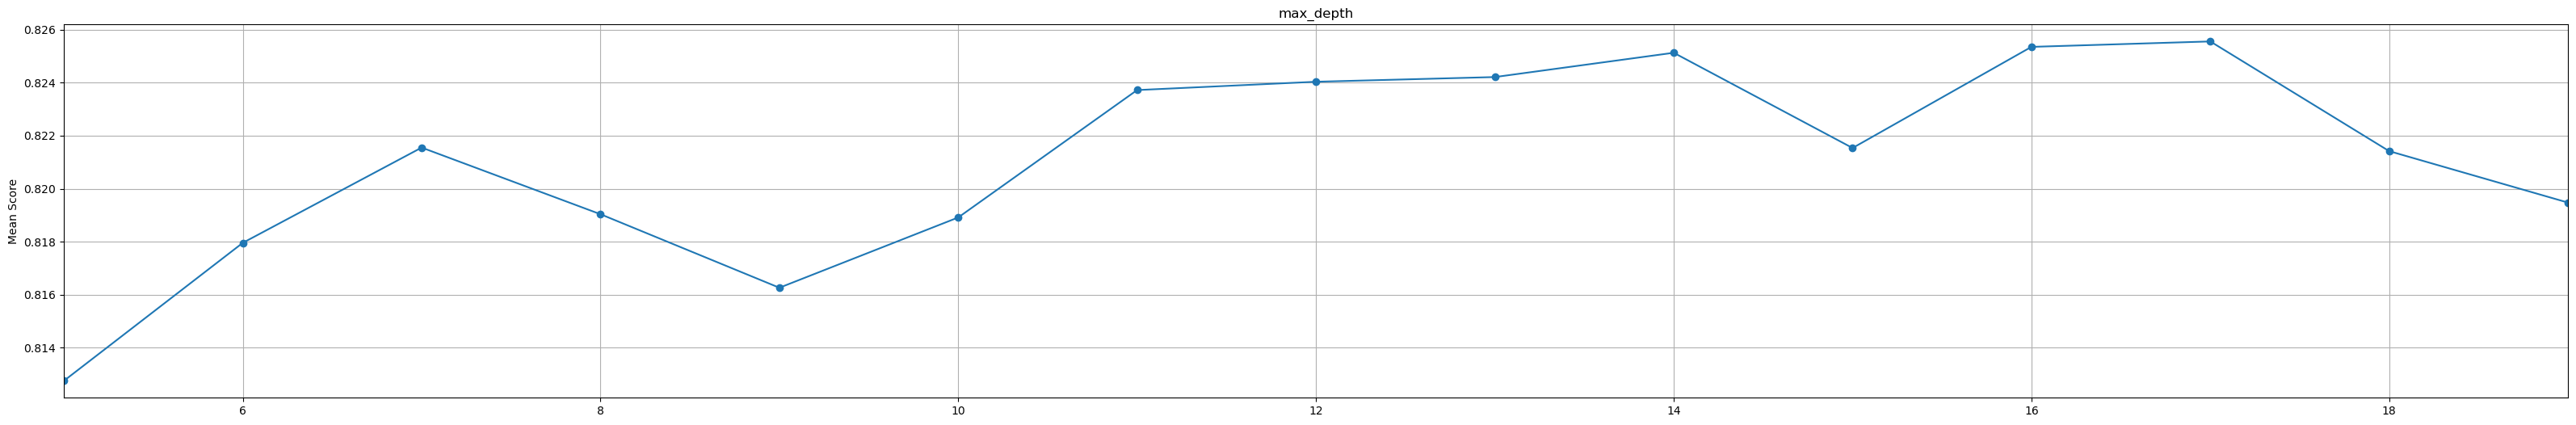

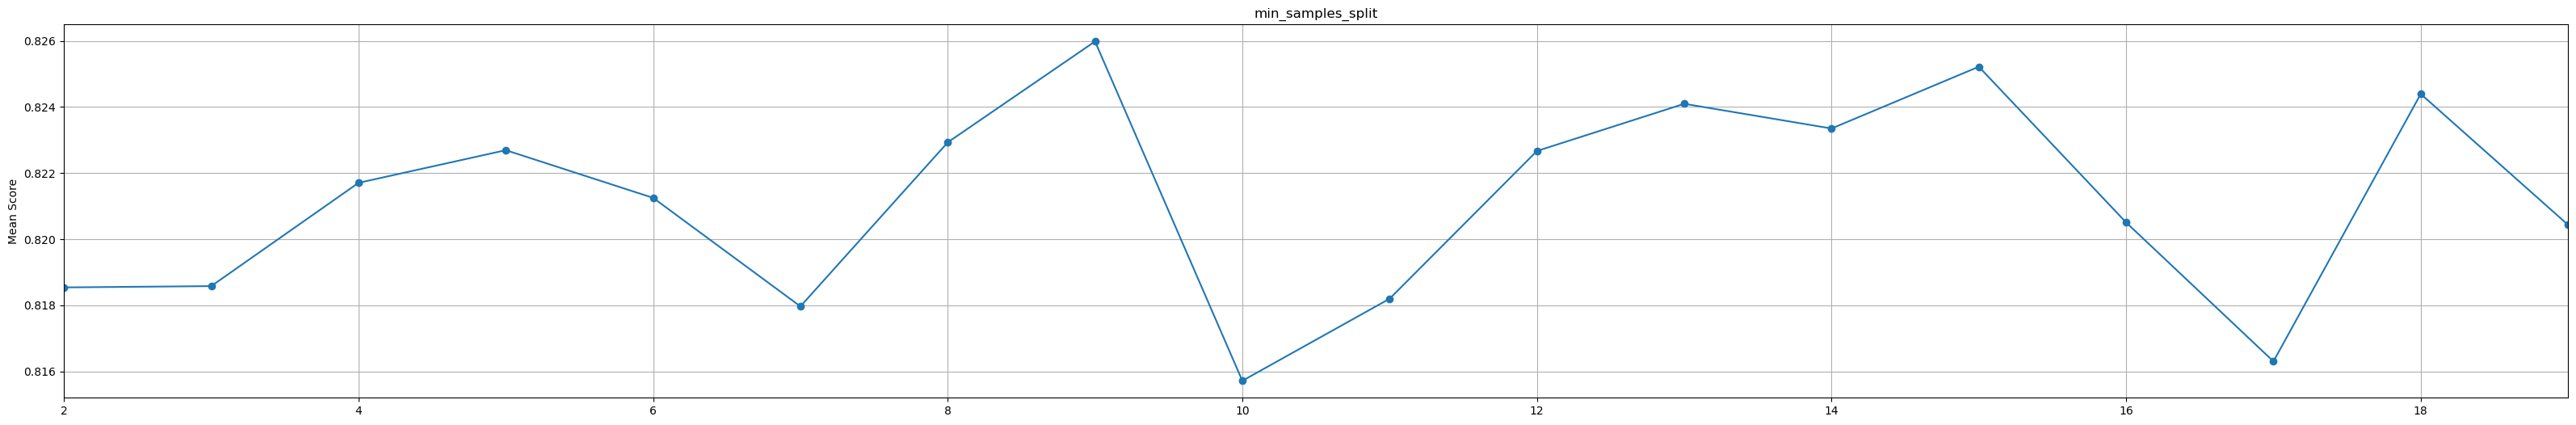

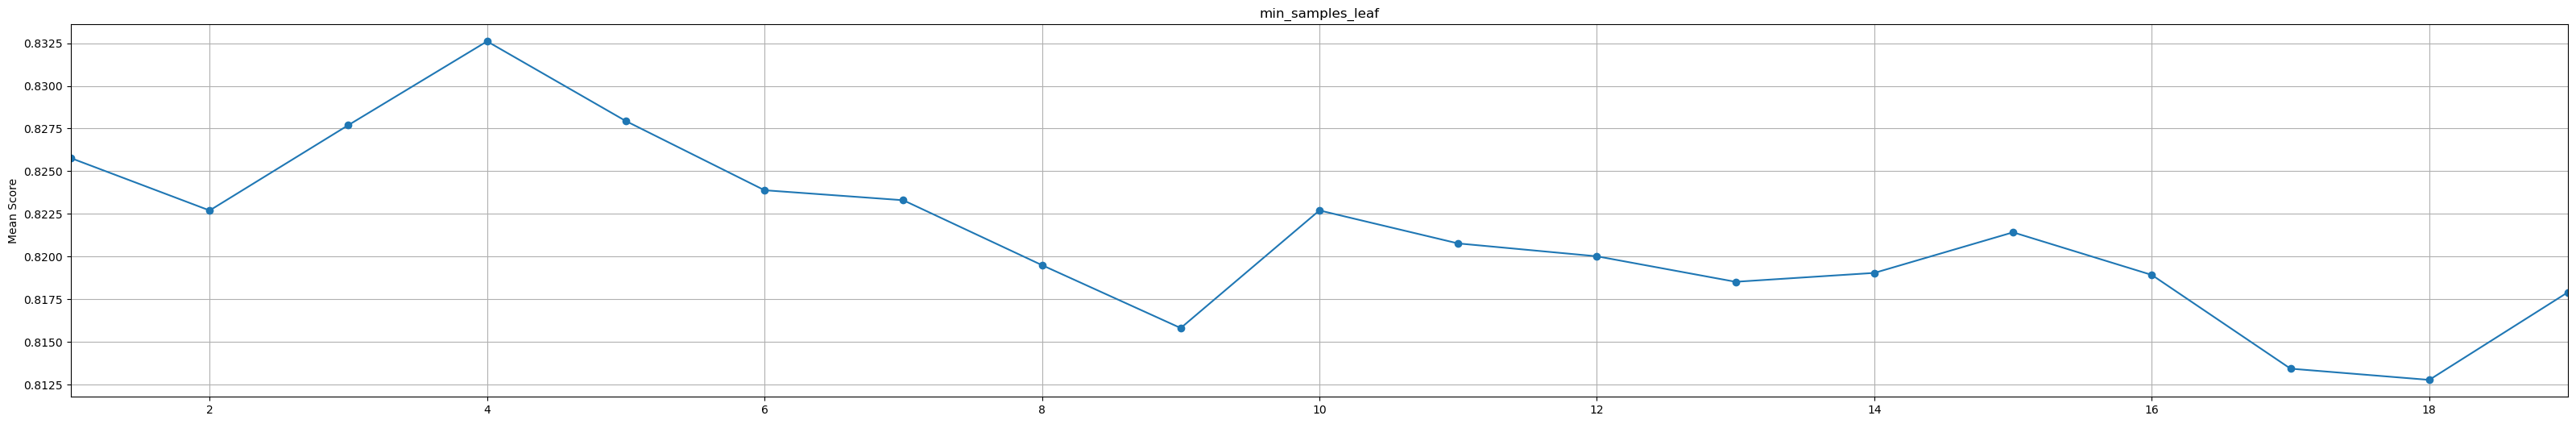

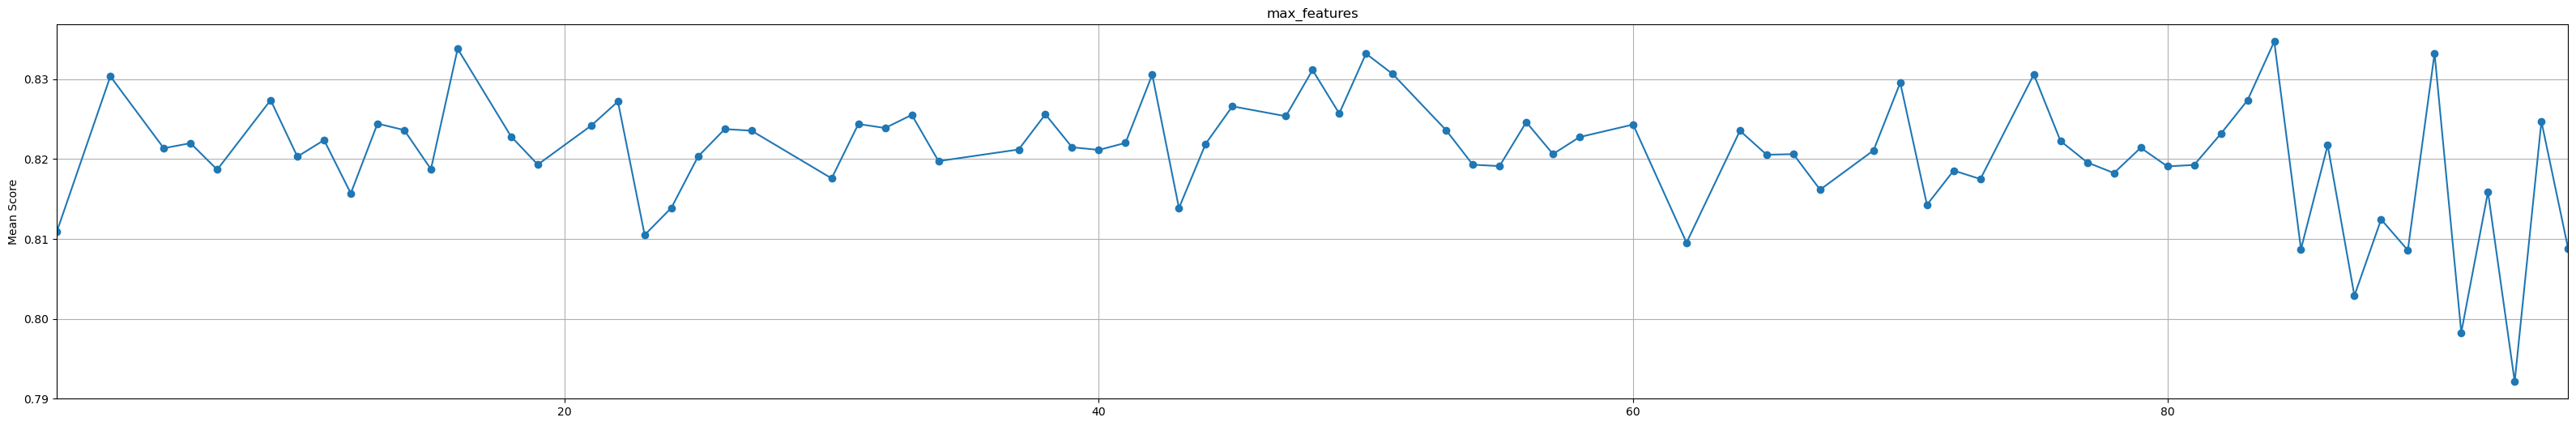

In [245]:
hyperparameters = ['n_estimators','max_depth','min_samples_split','min_samples_leaf','max_features'] 

for hyperparam_name in hyperparameters:
    
    hyperparam_values = rf_rand_search.cv_results_['param_' + hyperparam_name] 
    mean_scores = rf_rand_search.cv_results_['mean_test_score']
    
    # extract all scores for each hyperparameter value 
    hyperparam_tot_scores = dict()
    for value, score in zip(hyperparam_values, mean_scores):
        if value not in hyperparam_tot_scores: 
            hyperparam_tot_scores[value] = [score]
        else:
            hyperparam_tot_scores[value].append(score) 
    
    # mean scores for each hyperparameter value
    sorted_hyperparams = sorted(hyperparam_tot_scores.keys())
    averaged_scores = [np.nanmean(hyperparam_tot_scores[val]) for val in sorted_hyperparams]

    plt.figure(figsize=(40, 6))
    plt.plot(sorted_hyperparams, averaged_scores, marker='o', linestyle='-')

    plt.xlim([min(sorted_hyperparams), max(sorted_hyperparams)])
    plt.ylabel('Mean Score')
    plt.title(f'{hyperparam_name}')
    plt.grid(True)

    plt.show()

In [66]:
hyperpar = {
    'n_estimators': [30,40,50],  
    'criterion': ['log_loss'],  
    'max_depth': [10,11,12], 
    'min_samples_split': [5,9,15],  
    'min_samples_leaf':[3,4,5],  
    'max_features': [20,40,60],
    'bootstrap': [True], 
}

# search all combinations of above values
rf_grid_search = GridSearchCV(rf, 
                              param_grid=hyperpar, 
                              scoring='f1_weighted', 
                              cv=5, 
                              verbose=1, 
                              n_jobs=-1)

rf_grid_search.fit(expl_train, resp_train)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


/env/lib/python3.10/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


GridSearchCV(cv=5, estimator=RandomForestClassifier(n_jobs=-1), n_jobs=-1,
             param_grid={'bootstrap': [True], 'criterion': ['log_loss'],
                         'max_depth': [10, 11, 12],
                         'max_features': [20, 40, 60],
                         'min_samples_leaf': [3, 4, 5],
                         'min_samples_split': [5, 9, 15],
                         'n_estimators': [30, 40, 50]},
             scoring='f1_weighted', verbose=1)

In [67]:
rf_grid_search.best_params_, rf_grid_search.best_score_ 

({'bootstrap': True,
  'criterion': 'log_loss',
  'max_depth': 10,
  'max_features': 20,
  'min_samples_leaf': 5,
  'min_samples_split': 5,
  'n_estimators': 50},
 0.8432662530599109)

In [68]:
# best model
rf_best = rf_grid_search.best_estimator_

In [70]:
# save best model
from joblib import dump
dump(rf_best, f'RF_urban_classifier.joblib')

['RF_urban_classifier.joblib']

### Feature importance

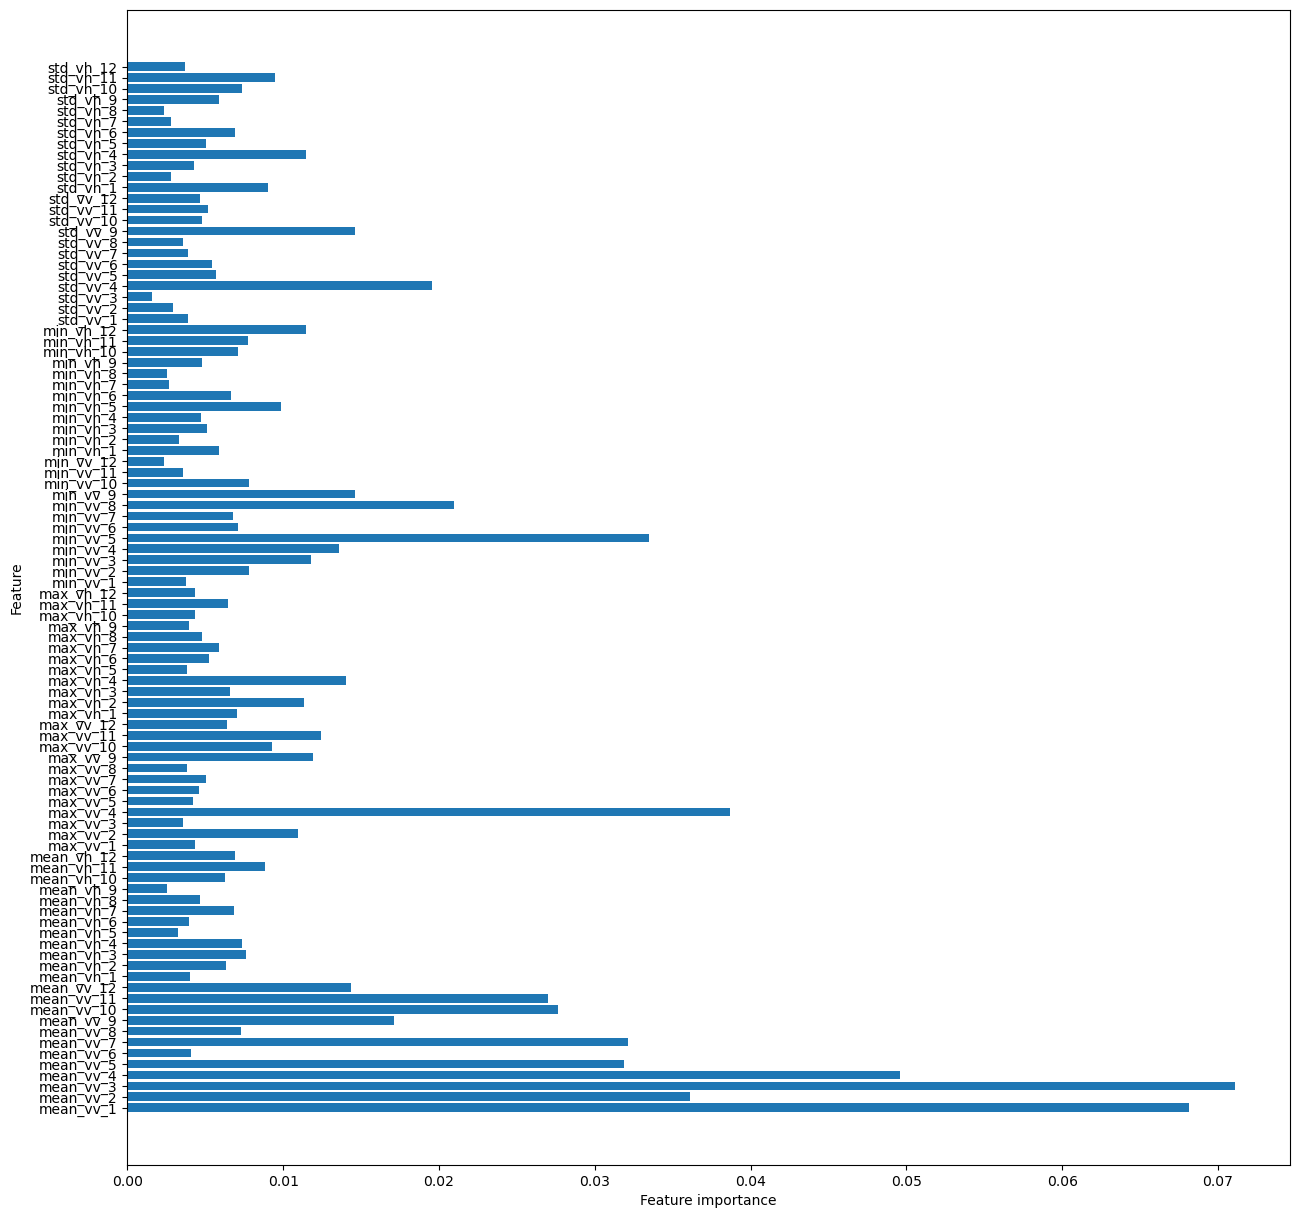

In [73]:
feat_importances = rf_best.feature_importances_
rf_importance = zip(predictors, feat_importances)
    
plt.figure(figsize=(15, 15))
plt.barh(predictors, feat_importances)
plt.xlabel('Feature importance')
plt.ylabel('Feature')
plt.show()

### Model performance same area

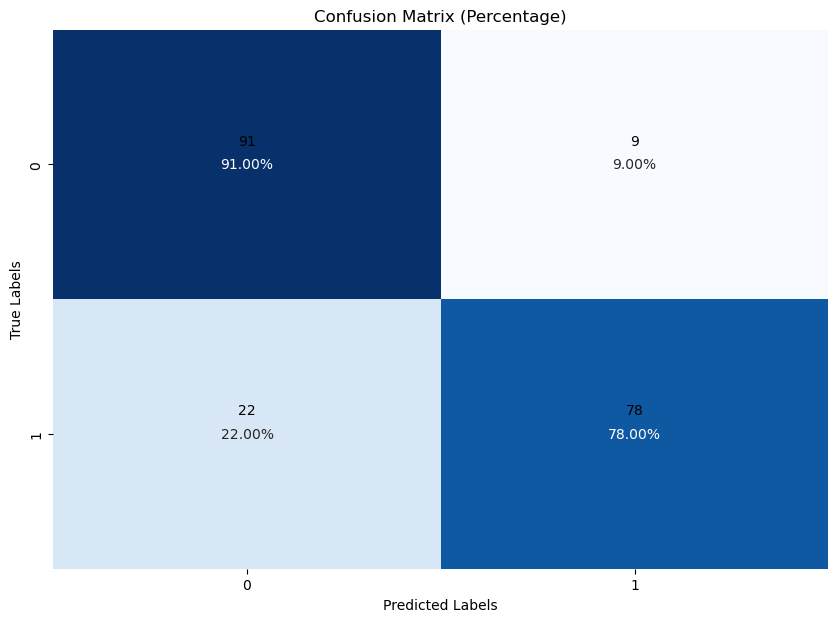

Accuracy: 0.8450
Weighted F1 Score: 0.8443
Weighted Precision: 0.8509
Weighted Recall: 0.8450


In [85]:
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc, f1_score, precision_score, recall_score, classification_report, average_precision_score

# true labels and predictions
y_true = resp_test
y_pred = rf_best.predict(expl_test[predictors])

cm = confusion_matrix(y_true, y_pred)

# show percentages (recall)
cm_normalised = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(cm_normalised, annot=True, fmt='.2%', cmap='Blues', cbar=False, ax=ax)
ax.set_xlabel('Predicted Labels')
ax.set_ylabel('True Labels')
ax.set_title('Confusion Matrix (Percentage)')

# add counts in the cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j+0.5, i+0.5, f'{cm[i, j]}\n', 
                ha='center', va='bottom', color='black')

plt.show()

# metrics
accuracy = accuracy_score(y_true, y_pred)
f1_weighted = f1_score(y_true, y_pred, average='weighted')
precision_weighted = precision_score(y_true, y_pred, average='weighted')
recall_weighted = recall_score(y_true, y_pred, average='weighted')

print(f'Accuracy: {accuracy:.4f}')
print(f'Weighted F1 Score: {f1_weighted:.4f}')
print(f'Weighted Precision: {precision_weighted:.4f}')
print(f'Weighted Recall: {recall_weighted:.4f}')

In [86]:
# classification summary 
report = classification_report(y_true, y_pred, output_dict=True)

report_df = pd.DataFrame(report).transpose()

print(report_df)

              precision  recall  f1-score  support
0              0.805310   0.910  0.854460  100.000
1              0.896552   0.780  0.834225  100.000
accuracy       0.845000   0.845  0.845000    0.845
macro avg      0.850931   0.845  0.844342  200.000
weighted avg   0.850931   0.845  0.844342  200.000


### Plot map in a different area

In [246]:
# Area of interest
aoi_bbox = BoundingBox(
    left=149.108304,
    bottom=-35.408159,
    right= 149.184827,
    top=-35.322674,
    crs="EPSG:4326"
)
aoi_bbox.explore()

In [103]:
ds_test = dc.load(
    product=product_to_load,
    measurements=measurements_to_load,
    lat=(aoi_bbox.bottom, aoi_bbox.top),
    lon=(aoi_bbox.left, aoi_bbox.right),
    output_crs=output_crs,
    resolution=(output_res, -output_res),
    time=(start_date, end_date),
    group_by=groupy_by_operation,
    dask_chunks={},
    skip_broken_datasets=True
)
ds_test

<xarray.Dataset> Size: 118MB
Dimensions:      (time: 62, y: 518, x: 409)
Coordinates:
  * time         (time) datetime64[ns] 496B 2024-06-05T19:24:48.043584 ... 20...
  * y            (y) float64 4kB -3.972e+06 -3.972e+06 ... -3.962e+06 -3.962e+06
  * x            (x) float64 3kB 1.555e+06 1.555e+06 ... 1.547e+06 1.547e+06
    spatial_ref  int32 4B 3577
Data variables:
    VV_gamma0    (time, y, x) float32 53MB dask.array<chunksize=(1, 518, 409), meta=np.ndarray>
    VH_gamma0    (time, y, x) float32 53MB dask.array<chunksize=(1, 518, 409), meta=np.ndarray>
    mask         (time, y, x) uint8 13MB dask.array<chunksize=(1, 518, 409), meta=np.ndarray>
Attributes:
    crs:           EPSG:3577
    grid_mapping:  spatial_ref

In [104]:
ds_test = ds_test.compute()

/env/lib/python3.10/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(
/env/lib/python3.10/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


In [146]:
def flatten_months(ds):
    months = ds['month'].values

    new_vars = {}
    for var in ds.data_vars:
        for i in range(ds.sizes['month']):
            mlabel = months[i]
            label = f"{int(mlabel)}"
            
            da = ds[var].isel(month=i)

            da = da.reset_coords('month', drop=True)

            new_vars[f"{var}_{label}"] = da

    return xr.Dataset(new_vars)


In [247]:
def process_cube(ds, predictors, model):
    ds["VV_gamma0_filtered"] = apply_lee_filter(ds["VV_gamma0"], size=3)
    ds["VH_gamma0_filtered"] = apply_lee_filter(ds["VH_gamma0"], size=3)

    ds["VV_gamma0_masked"] = xr.where(ds.mask == 0, ds["VV_gamma0_filtered"], np.nan)
    ds["VH_gamma0_masked"] = xr.where(ds.mask == 0, ds["VH_gamma0_filtered"], np.nan)

    ds_reduced = ds.drop_vars([
        'VV_gamma0', 'VH_gamma0', 'mask',
        'VV_gamma0_filtered', 'VH_gamma0_filtered'
    ])

    ds_grouped = ds_reduced.groupby('time.month')
    ds_final = ds_grouped.mean().drop_vars(['VV_gamma0_masked', 'VH_gamma0_masked'])

    ds_final['mean_vv'] = ds_grouped.mean()['VV_gamma0_masked']
    ds_final['mean_vh'] = ds_grouped.mean()['VH_gamma0_masked']
    ds_final['max_vv'] = ds_grouped.max()['VV_gamma0_masked']
    ds_final['max_vh'] = ds_grouped.max()['VH_gamma0_masked']
    ds_final['min_vv'] = ds_grouped.min()['VV_gamma0_masked']
    ds_final['min_vh'] = ds_grouped.min()['VH_gamma0_masked']
    ds_final['std_vv'] = ds_grouped.std()['VV_gamma0_masked']
    ds_final['std_vh'] = ds_grouped.std()['VH_gamma0_masked']

    ds_final = flatten_months(ds_final)

    ds_final = ds_final.sortby('x')  # west to east
    ds_final = ds_final.sortby('y', ascending=False)  # north to south

    input_array = ds_final[predictors].to_array().values
    nan_mask = np.isnan(input_array)
    nan_mask_2d = np.sum(np.where(nan_mask, 1, 0), axis=0)
    input_array = np.where(nan_mask, 0, input_array) # replace NaN with zeros to run model without issues

    n_vars, y_size, x_size = input_array.shape
    input_rf = input_array.reshape((n_vars, -1)).swapaxes(0, 1)

    predicted_urban = model.predict(input_rf)
    predicted_urban_2d = predicted_urban.reshape((y_size, x_size))
    predicted_urban_2d = np.where(nan_mask_2d > 0, np.nan, predicted_urban_2d) # put back NaNs, if there were any

    # format array as datarray with coords and georeferenced
    out_da = xr.DataArray(
        predicted_urban_2d,
        dims=('y', 'x'),
        coords={'y': ds_final['y'].values, 'x': ds_final['x'].values},
        name='predicted_urban'
    )
    crs = ds_final.odc.crs
    out_da = assign_crs(out_da, crs)

    return out_da


In [248]:
test = process_cube(ds_test, predictors, rf_best)

/tmp/ipykernel_2754/285646438.py:26: RuntimeWarning: invalid value encountered in divide
  img_weights = img_variance / (img_variance + overall_variance)
/env/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [249]:
test

<xarray.DataArray 'predicted_urban' (y: 518, x: 409)> Size: 2MB
array([[1., 1., 1., ..., 1., 0., 0.],
       [1., 1., 1., ..., 0., 0., 0.],
       [1., 1., 1., ..., 1., 0., 0.],
       ...,
       [1., 1., 1., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.]])
Coordinates:
  * y            (y) float64 4kB -3.962e+06 -3.962e+06 ... -3.972e+06 -3.972e+06
  * x            (x) float64 3kB 1.547e+06 1.547e+06 ... 1.555e+06 1.555e+06
    spatial_ref  int32 4B 3577

In [250]:
test_wgs84 = test.rio.reproject("EPSG:4326")

# Save to NetCDF
test_wgs84.to_netcdf("predicted_urban_wgs84.nc")

In [238]:
# load geomedian to show side by side with classification
rgb_test = dc.load(
    product=['ga_ls8cls9c_gm_cyear_3'],
    measurements=['nbart_red','nbart_green','nbart_blue'],
    lat=(aoi_bbox.bottom, aoi_bbox.top),
    lon=(aoi_bbox.left, aoi_bbox.right),
    output_crs=output_crs,
    resolution=(output_res, -output_res),
    time=('2024-01-01', '2024-01-01'),
    dask_chunks={},
    skip_broken_datasets=True
)

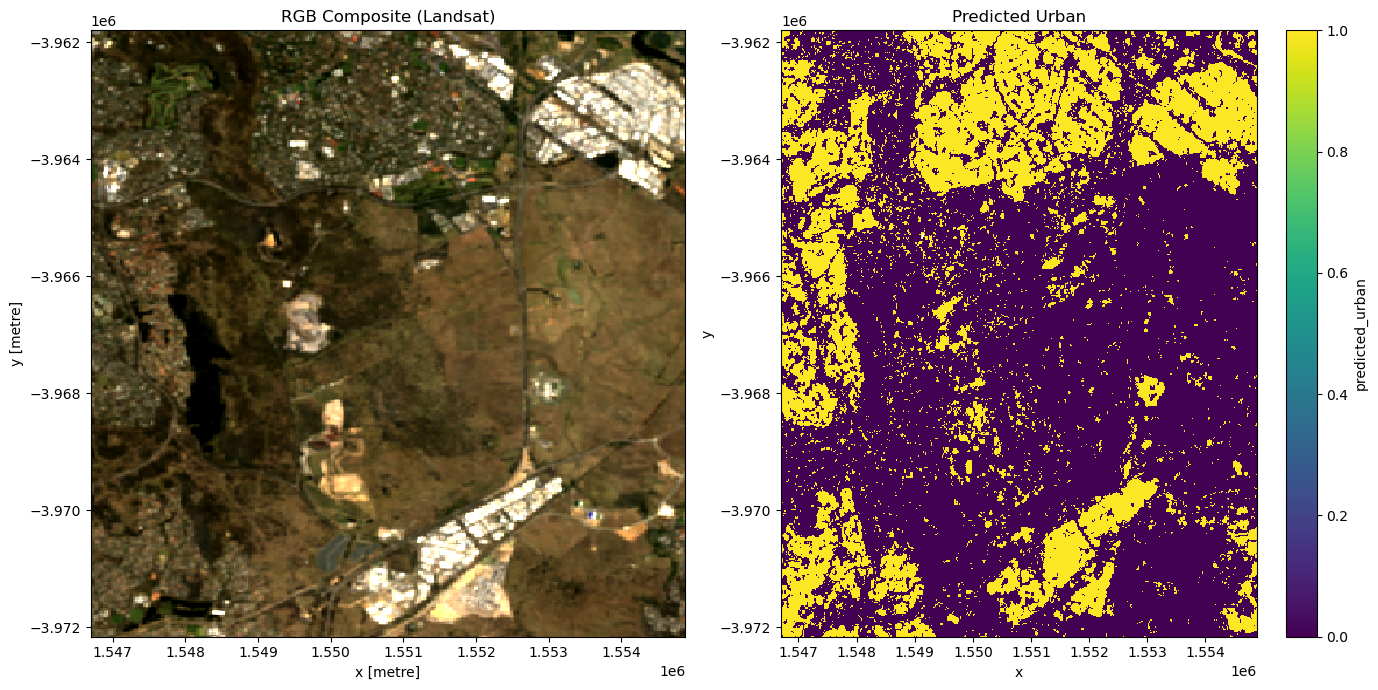

In [239]:
rgb = rgb_test.isel(time=0)[['nbart_red', 'nbart_green', 'nbart_blue']].to_array()

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# RGB composite
rgb.plot.imshow(ax=axes[0], robust=True)
axes[0].set_title('RGB Composite (Landsat)')

# Classification result
test.plot.imshow(ax=axes[1], cmap='viridis')
axes[1].set_title('Predicted Urban')

plt.tight_layout()
plt.show()


In [231]:
# convert classificiation to vector
import geopandas as gpd
import rasterio.features
from shapely.geometry import shape

data = test_wgs84.values
transform = test_wgs84.rio.transform()

# get shapes where value == 1, ie urban
shapes = rasterio.features.shapes(data.astype('uint8'), transform=transform)
urban_shapes = [
    {"geometry": shape(geom), "properties": {"value": value}}
    for geom, value in shapes
    if value == 1
]

gdf = gpd.GeoDataFrame.from_features(urban_shapes, crs="EPSG:4326")

gdf.to_file("predicted_urban.geojson", driver="GeoJSON")


/tmp/ipykernel_2754/3079083944.py:11: RuntimeWarning: invalid value encountered in cast
  shapes = rasterio.features.shapes(data.astype('uint8'), transform=transform)
